In [76]:
!pip install -q roboflow

from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("Roboflow_api")
rf = Roboflow(api_key=secret_value_0)
project = rf.workspace("boxing-aeztm").project("my-first-project-zjcng")
dataset = project.version(4).download("folder")

images_path = dataset.location

loading Roboflow workspace...
loading Roboflow project...


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import Adam
import numpy as np
from tqdm import tqdm
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [46]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except:
    !pip install -q albumentations
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

## Load Data

In [47]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussNoise(p=0.3),
    A.Blur(blur_limit=5, p=0.3),
    A.Affine(scale=(0.9, 1.1), translate_percent=0.1, rotate=(-20, 20), p=0.5),
    A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class_mapping = {
    "Hit": "land",
    "Block": "miss",
    "Miss": "miss",
    "None": "miss"
}

labels = {"miss": 0, "land": 1}
data = []
miss_count = 0
land_count = 0

for split in ["train", "valid"]:
    split_path = os.path.join(images_path, split)
    if not os.path.exists(split_path):
        continue
    
    for src_class in ["Hit", "Miss", "Block", "None"]:
        class_dir = os.path.join(split_path, src_class)
        if not os.path.exists(class_dir):
            continue
        
        dst_class = class_mapping[src_class]
        label = labels[dst_class]
        
        for img_file in os.listdir(class_dir):
            if not img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue
            
            img_path = os.path.join(class_dir, img_file)
            image = cv2.imread(img_path)
            
            if image is None:
                continue
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            data.append((image, label))
            
            if dst_class == "miss":
                miss_count += 1
            else:
                land_count += 1

print(f"Total: {len(data)} | Miss: {miss_count} | Land: {land_count}")
print(f"Class Ratio: {miss_count/land_count:.2f}:1 (Miss:Land)")
print(f"Class Weight for Miss: {land_count/miss_count:.4f}")

Total: 4015 | Miss: 1243 | Land: 2772
Class Ratio: 0.45:1 (Miss:Land)
Class Weight for Miss: 2.2301


## Dataset Class

In [48]:

class PunchDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image, label = self.data[idx]
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        label = torch.tensor(label).long()
        
        return image, label

## Train/Test Split

In [49]:
train_len = int(0.7 * len(data))
val_len = int(0.15 * len(data))
test_len = len(data) - train_len - val_len

torch.manual_seed(42)
np.random.seed(42)

train_data, val_data, test_data = random_split(data, [train_len, val_len, test_len])

train_data_list = [data[i] for i in train_data.indices]
val_data_list = [data[i] for i in val_data.indices]
test_data_list = [data[i] for i in test_data.indices]

train_dataset = PunchDataset(train_data_list, transform=train_transform)
val_dataset = PunchDataset(val_data_list, transform=test_transform)
test_dataset = PunchDataset(test_data_list, transform=test_transform)

batch_size = 32 if device == "cuda" else 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                         num_workers=2, pin_memory=True if device == "cuda" else False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=2, pin_memory=True if device == "cuda" else False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=2, pin_memory=True if device == "cuda" else False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)} | Batch: {batch_size}")

Train: 2810 | Val: 602 | Test: 603 | Batch: 32


## Channel Attention

In [50]:

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out.expand_as(x)

## Spatial Attention

In [51]:

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attention = self.sigmoid(self.conv(x_cat))
        
        return x * attention

## CBAM

In [52]:

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

## HitNet Model

In [53]:
class HitNet(nn.Module):
    def __init__(self, dropout_rate=0.5, attention_type='cbam'):
        super(HitNet, self).__init__()
        
        self.attention_type = attention_type
        
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )
        
        if attention_type == 'cbam':
            self.attention = CBAM(channels=256, reduction=16)
        elif attention_type == 'channel':
            self.attention = ChannelAttention(channels=256, reduction=16)
        elif attention_type == 'spatial':
            self.attention = SpatialAttention(kernel_size=7)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.4),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        x = self.backbone(x)
        if self.attention_type != 'none':
            x = self.attention(x)
        x = self.global_pool(x).flatten(1)
        out = self.classifier(x)
        return out

## Initialize Model

In [54]:
model_cbam = HitNet(dropout_rate=0.5, attention_type='cbam').to(device)
model_channel = HitNet(dropout_rate=0.5, attention_type='channel').to(device)
model_spatial = HitNet(dropout_rate=0.5, attention_type='spatial').to(device)
model_baseline = HitNet(dropout_rate=0.5, attention_type='none').to(device)

total_samples = miss_count + land_count
weight_miss = total_samples / (2 * miss_count)
weight_land = total_samples / (2 * land_count)

class_weights = torch.tensor([weight_miss, weight_land]).to(device)
print(f"Class Weights: Miss={weight_miss:.4f}, Land={weight_land:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer_cbam = Adam(model_cbam.parameters(), lr=0.0001, weight_decay=1e-4)
optimizer_channel = Adam(model_channel.parameters(), lr=0.0001, weight_decay=1e-4)
optimizer_spatial = Adam(model_spatial.parameters(), lr=0.0001, weight_decay=1e-4)
optimizer_baseline = Adam(model_baseline.parameters(), lr=0.0001, weight_decay=1e-4)

scheduler_cbam = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cbam, mode='min', factor=0.5, patience=5)
scheduler_channel = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_channel, mode='min', factor=0.5, patience=5)
scheduler_spatial = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_spatial, mode='min', factor=0.5, patience=5)
scheduler_baseline = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_baseline, mode='min', factor=0.5, patience=5)

print(f"\nCBAM Model - Parameters: {sum(p.numel() for p in model_cbam.parameters()):,}")
print(f"Channel Attention Model - Parameters: {sum(p.numel() for p in model_channel.parameters()):,}")
print(f"Spatial Attention Model - Parameters: {sum(p.numel() for p in model_spatial.parameters()):,}")
print(f"Baseline Model - Parameters: {sum(p.numel() for p in model_baseline.parameters()):,}")

Class Weights: Miss=1.6150, Land=0.7242

CBAM Model - Parameters: 439,332
Channel Attention Model - Parameters: 439,234
Spatial Attention Model - Parameters: 431,140
Baseline Model - Parameters: 431,042


## Training and Validation Functions

In [55]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

## Training Loop

In [56]:
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 8

results = {
    'cbam': {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': [], 'best_val_acc': 0.0, 'best_val_loss': float('inf')},
    'channel': {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': [], 'best_val_acc': 0.0, 'best_val_loss': float('inf')},
    'spatial': {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': [], 'best_val_acc': 0.0, 'best_val_loss': float('inf')},
    'baseline': {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': [], 'best_val_acc': 0.0, 'best_val_loss': float('inf')}
}

## Train Baseline Model

In [58]:
print(f"\n{'='*60}")
print(f"Training: BASELINE MODEL (NO ATTENTION)")
print(f"{'='*60}")

early_stop_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model_baseline, train_loader, criterion, optimizer_baseline, device)
    results['baseline']['train_losses'].append(train_loss)
    results['baseline']['train_accs'].append(train_acc)
    
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model_baseline, val_loader, criterion, device)
    results['baseline']['val_losses'].append(val_loss)
    results['baseline']['val_accs'].append(val_acc)
    
    scheduler_baseline.step(val_loss)
    current_lr = optimizer_baseline.param_groups[0]['lr']
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")
    
    if val_loss < results['baseline']['best_val_loss']:
        results['baseline']['best_val_loss'] = val_loss
        results['baseline']['best_val_acc'] = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_baseline.state_dict(),
            'optimizer_state_dict': optimizer_baseline.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'HitNet_Baseline_Best.pth')
        print(f"Best model saved | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"No improvement for {early_stop_counter} epoch(s)")
        
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBaseline - Best Val Acc: {results['baseline']['best_val_acc']:.2f}%")
print(f"Baseline - Best Val Loss: {results['baseline']['best_val_loss']:.4f}")


Training: BASELINE MODEL (NO ATTENTION)

Epoch 1/50


Train Loss: 0.7349 | Train Acc: 48.51%
Val Loss: 0.7033 | Val Acc: 30.40%
Learning Rate: 0.000100
Best model saved | Val Acc: 30.40% | Val Loss: 0.7033

Epoch 2/50


Train Loss: 0.7299 | Train Acc: 47.33%
Val Loss: 0.7013 | Val Acc: 30.40%
Learning Rate: 0.000100
Best model saved | Val Acc: 30.40% | Val Loss: 0.7013

Epoch 3/50


Train Loss: 0.7189 | Train Acc: 49.57%
Val Loss: 0.6946 | Val Acc: 32.72%
Learning Rate: 0.000100
Best model saved | Val Acc: 32.72% | Val Loss: 0.6946

Epoch 4/50


Train Loss: 0.7207 | Train Acc: 48.26%
Val Loss: 0.6928 | Val Acc: 37.54%
Learning Rate: 0.000100
Best model saved | Val Acc: 37.54% | Val Loss: 0.6928

Epoch 5/50


...

Train Loss: 0.6503 | Train Acc: 64.38%
Val Loss: 0.5816 | Val Acc: 71.59%
Learning Rate: 0.000100
Best model saved | Val Acc: 71.59% | Val Loss: 0.5816

Epoch 47/50


Train Loss: 0.6452 | Train Acc: 64.80%
Val Loss: 0.5875 | Val Acc: 68.77%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 48/50


Train Loss: 0.6434 | Train Acc: 66.09%
Val Loss: 0.5793 | Val Acc: 72.59%
Learning Rate: 0.000100
Best model saved | Val Acc: 72.59% | Val Loss: 0.5793

Epoch 49/50


Train Loss: 0.6431 | Train Acc: 64.27%
Val Loss: 0.5782 | Val Acc: 70.60%
Learning Rate: 0.000100
Best model saved | Val Acc: 70.60% | Val Loss: 0.5782

Epoch 50/50


Train Loss: 0.6460 | Train Acc: 64.20%
Val Loss: 0.5771 | Val Acc: 74.42%
Learning Rate: 0.000100
Best model saved | Val Acc: 74.42% | Val Loss: 0.5771

Baseline - Best Val Acc: 74.42%
Baseline - Best Val Loss: 0.5771


## Train Spatial Attention Model

In [59]:
print(f"\n{'='*60}")
print(f"Training: SPATIAL ATTENTION MODEL")
print(f"{'='*60}")

early_stop_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model_spatial, train_loader, criterion, optimizer_spatial, device)
    results['spatial']['train_losses'].append(train_loss)
    results['spatial']['train_accs'].append(train_acc)
    
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model_spatial, val_loader, criterion, device)
    results['spatial']['val_losses'].append(val_loss)
    results['spatial']['val_accs'].append(val_acc)
    
    scheduler_spatial.step(val_loss)
    current_lr = optimizer_spatial.param_groups[0]['lr']
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")
    
    if val_loss < results['spatial']['best_val_loss']:
        results['spatial']['best_val_loss'] = val_loss
        results['spatial']['best_val_acc'] = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_spatial.state_dict(),
            'optimizer_state_dict': optimizer_spatial.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'HitNet_Spatial_Best.pth')
        print(f"Best model saved | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"No improvement for {early_stop_counter} epoch(s)")
        
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nSpatial - Best Val Acc: {results['spatial']['best_val_acc']:.2f}%")
print(f"Spatial - Best Val Loss: {results['spatial']['best_val_loss']:.4f}")


Training: SPATIAL ATTENTION MODEL

Epoch 1/50


Train Loss: 0.7405 | Train Acc: 44.63%
Val Loss: 0.7015 | Val Acc: 66.28%
Learning Rate: 0.000100
Best model saved | Val Acc: 66.28% | Val Loss: 0.7015

Epoch 2/50


Train Loss: 0.7442 | Train Acc: 44.66%
Val Loss: 0.6947 | Val Acc: 51.66%
Learning Rate: 0.000100
Best model saved | Val Acc: 51.66% | Val Loss: 0.6947

Epoch 3/50


Train Loss: 0.7297 | Train Acc: 46.80%
Val Loss: 0.6958 | Val Acc: 69.93%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 4/50


Train Loss: 0.7208 | Train Acc: 49.15%
Val Loss: 0.6945 | Val Acc: 72.43%
Learning Rate: 0.000100
Best model saved | Val Acc: 72.43% | Val Loss: 0.6945

Epoch 5/50


...

Train Loss: 0.6418 | Train Acc: 66.09%
Val Loss: 0.5672 | Val Acc: 74.09%
Learning Rate: 0.000100
No improvement for 2 epoch(s)

Epoch 47/50


Train Loss: 0.6319 | Train Acc: 66.48%
Val Loss: 0.5643 | Val Acc: 74.42%
Learning Rate: 0.000100
Best model saved | Val Acc: 74.42% | Val Loss: 0.5643

Epoch 48/50


Train Loss: 0.6377 | Train Acc: 65.73%
Val Loss: 0.5626 | Val Acc: 75.58%
Learning Rate: 0.000100
Best model saved | Val Acc: 75.58% | Val Loss: 0.5626

Epoch 49/50


Train Loss: 0.6290 | Train Acc: 67.05%
Val Loss: 0.5665 | Val Acc: 73.59%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 50/50


Train Loss: 0.6338 | Train Acc: 67.76%
Val Loss: 0.5665 | Val Acc: 73.26%
Learning Rate: 0.000100
No improvement for 2 epoch(s)

Spatial - Best Val Acc: 75.58%
Spatial - Best Val Loss: 0.5626


## Train Channel Attention Model

In [60]:
print(f"\n{'='*60}")
print(f"Training: CHANNEL ATTENTION MODEL")
print(f"{'='*60}")

early_stop_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model_channel, train_loader, criterion, optimizer_channel, device)
    results['channel']['train_losses'].append(train_loss)
    results['channel']['train_accs'].append(train_acc)
    
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model_channel, val_loader, criterion, device)
    results['channel']['val_losses'].append(val_loss)
    results['channel']['val_accs'].append(val_acc)
    
    scheduler_channel.step(val_loss)
    current_lr = optimizer_channel.param_groups[0]['lr']
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")
    
    if val_loss < results['channel']['best_val_loss']:
        results['channel']['best_val_loss'] = val_loss
        results['channel']['best_val_acc'] = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_channel.state_dict(),
            'optimizer_state_dict': optimizer_channel.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'HitNet_Channel_Best.pth')
        print(f"Best model saved | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"No improvement for {early_stop_counter} epoch(s)")
        
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nChannel - Best Val Acc: {results['channel']['best_val_acc']:.2f}%")
print(f"Channel - Best Val Loss: {results['channel']['best_val_loss']:.4f}")


Training: CHANNEL ATTENTION MODEL

Epoch 1/50


Train Loss: 0.7435 | Train Acc: 43.31%
Val Loss: 0.7023 | Val Acc: 42.86%
Learning Rate: 0.000100
Best model saved | Val Acc: 42.86% | Val Loss: 0.7023

Epoch 2/50


Train Loss: 0.7363 | Train Acc: 45.09%
Val Loss: 0.7003 | Val Acc: 30.40%
Learning Rate: 0.000100
Best model saved | Val Acc: 30.40% | Val Loss: 0.7003

Epoch 3/50


Train Loss: 0.7269 | Train Acc: 47.26%
Val Loss: 0.6931 | Val Acc: 40.03%
Learning Rate: 0.000100
Best model saved | Val Acc: 40.03% | Val Loss: 0.6931

Epoch 4/50


Train Loss: 0.7340 | Train Acc: 46.55%
Val Loss: 0.6934 | Val Acc: 43.36%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 5/50


...

Train Loss: 0.6394 | Train Acc: 66.26%
Val Loss: 0.5807 | Val Acc: 70.27%
Learning Rate: 0.000100
No improvement for 2 epoch(s)

Epoch 47/50


Train Loss: 0.6516 | Train Acc: 63.77%
Val Loss: 0.5782 | Val Acc: 71.43%
Learning Rate: 0.000100
Best model saved | Val Acc: 71.43% | Val Loss: 0.5782

Epoch 48/50


Train Loss: 0.6357 | Train Acc: 66.16%
Val Loss: 0.5772 | Val Acc: 70.43%
Learning Rate: 0.000100
Best model saved | Val Acc: 70.43% | Val Loss: 0.5772

Epoch 49/50


Train Loss: 0.6446 | Train Acc: 65.27%
Val Loss: 0.5713 | Val Acc: 73.59%
Learning Rate: 0.000100
Best model saved | Val Acc: 73.59% | Val Loss: 0.5713

Epoch 50/50


Train Loss: 0.6393 | Train Acc: 65.16%
Val Loss: 0.5708 | Val Acc: 72.92%
Learning Rate: 0.000100
Best model saved | Val Acc: 72.92% | Val Loss: 0.5708

Channel - Best Val Acc: 72.92%
Channel - Best Val Loss: 0.5708


## Train CBAM Model

In [61]:
print(f"{'='*60}")
print(f"Training: CBAM ATTENTION MODEL")
print(f"{'='*60}")

early_stop_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model_cbam, train_loader, criterion, optimizer_cbam, device)
    results['cbam']['train_losses'].append(train_loss)
    results['cbam']['train_accs'].append(train_acc)
    
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model_cbam, val_loader, criterion, device)
    results['cbam']['val_losses'].append(val_loss)
    results['cbam']['val_accs'].append(val_acc)
    
    scheduler_cbam.step(val_loss)
    current_lr = optimizer_cbam.param_groups[0]['lr']
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")
    
    if val_loss < results['cbam']['best_val_loss']:
        results['cbam']['best_val_loss'] = val_loss
        results['cbam']['best_val_acc'] = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_cbam.state_dict(),
            'optimizer_state_dict': optimizer_cbam.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'HitNet_CBAM_Best.pth')
        print(f"Best model saved | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"No improvement for {early_stop_counter} epoch(s)")
        
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nCBAM - Best Val Acc: {results['cbam']['best_val_acc']:.2f}%")
print(f"CBAM - Best Val Loss: {results['cbam']['best_val_loss']:.4f}")

Training: CBAM ATTENTION MODEL

Epoch 1/50


Train Loss: 0.7465 | Train Acc: 43.74%
Val Loss: 0.7041 | Val Acc: 30.40%
Learning Rate: 0.000100
Best model saved | Val Acc: 30.40% | Val Loss: 0.7041

Epoch 2/50


Train Loss: 0.7374 | Train Acc: 43.35%
Val Loss: 0.6975 | Val Acc: 33.39%
Learning Rate: 0.000100
Best model saved | Val Acc: 33.39% | Val Loss: 0.6975

Epoch 3/50


Train Loss: 0.7340 | Train Acc: 44.77%
Val Loss: 0.6971 | Val Acc: 39.87%
Learning Rate: 0.000100
Best model saved | Val Acc: 39.87% | Val Loss: 0.6971

Epoch 4/50


Train Loss: 0.7240 | Train Acc: 47.33%
Val Loss: 0.6943 | Val Acc: 38.54%
Learning Rate: 0.000100
Best model saved | Val Acc: 38.54% | Val Loss: 0.6943

Epoch 5/50


...

Train Loss: 0.6577 | Train Acc: 63.45%
Val Loss: 0.5643 | Val Acc: 74.42%
Learning Rate: 0.000100
Best model saved | Val Acc: 74.42% | Val Loss: 0.5643

Epoch 47/50


Train Loss: 0.6428 | Train Acc: 66.26%
Val Loss: 0.5660 | Val Acc: 75.58%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 48/50


Train Loss: 0.6495 | Train Acc: 64.34%
Val Loss: 0.5639 | Val Acc: 74.42%
Learning Rate: 0.000100
Best model saved | Val Acc: 74.42% | Val Loss: 0.5639

Epoch 49/50


Train Loss: 0.6498 | Train Acc: 65.09%
Val Loss: 0.5641 | Val Acc: 74.58%
Learning Rate: 0.000100
No improvement for 1 epoch(s)

Epoch 50/50


Train Loss: 0.6486 | Train Acc: 63.56%
Val Loss: 0.5633 | Val Acc: 75.25%
Learning Rate: 0.000100
Best model saved | Val Acc: 75.25% | Val Loss: 0.5633

CBAM - Best Val Acc: 75.25%
CBAM - Best Val Loss: 0.5633


## Plot Training History

In [74]:
print(f"\n{'='*70}")
print("FINAL COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"{'Model':<20} {'Best Val Acc':<15} {'Best Val Loss':<15}")
print(f"{'-'*70}")
print(f"{'CBAM':<20} {results['cbam']['best_val_acc']:>10.2f}%    {results['cbam']['best_val_loss']:>10.4f}")
print(f"{'Channel Attention':<20} {results['channel']['best_val_acc']:>10.2f}%    {results['channel']['best_val_loss']:>10.4f}")
print(f"{'Spatial Attention':<20} {results['spatial']['best_val_acc']:>10.2f}%    {results['spatial']['best_val_loss']:>10.4f}")
print(f"{'Baseline (No Att)':<20} {results['baseline']['best_val_acc']:>10.2f}%    {results['baseline']['best_val_loss']:>10.4f}")
print(f"{'='*70}")

best_model_name = max(results.keys(), key=lambda k: results[k]['best_val_acc'])
print(f"\nBest Model: {best_model_name.upper()}")
print(f"Validation Accuracy: {results[best_model_name]['best_val_acc']:.2f}%")


FINAL COMPARISON SUMMARY
Model                Best Val Acc    Best Val Loss  
----------------------------------------------------------------------
CBAM                      75.25%        0.5633
Channel Attention         72.92%        0.5708
Spatial Attention         75.58%        0.5626
Baseline (No Att)         74.42%        0.5771

Best Model: SPATIAL
Validation Accuracy: 75.58%


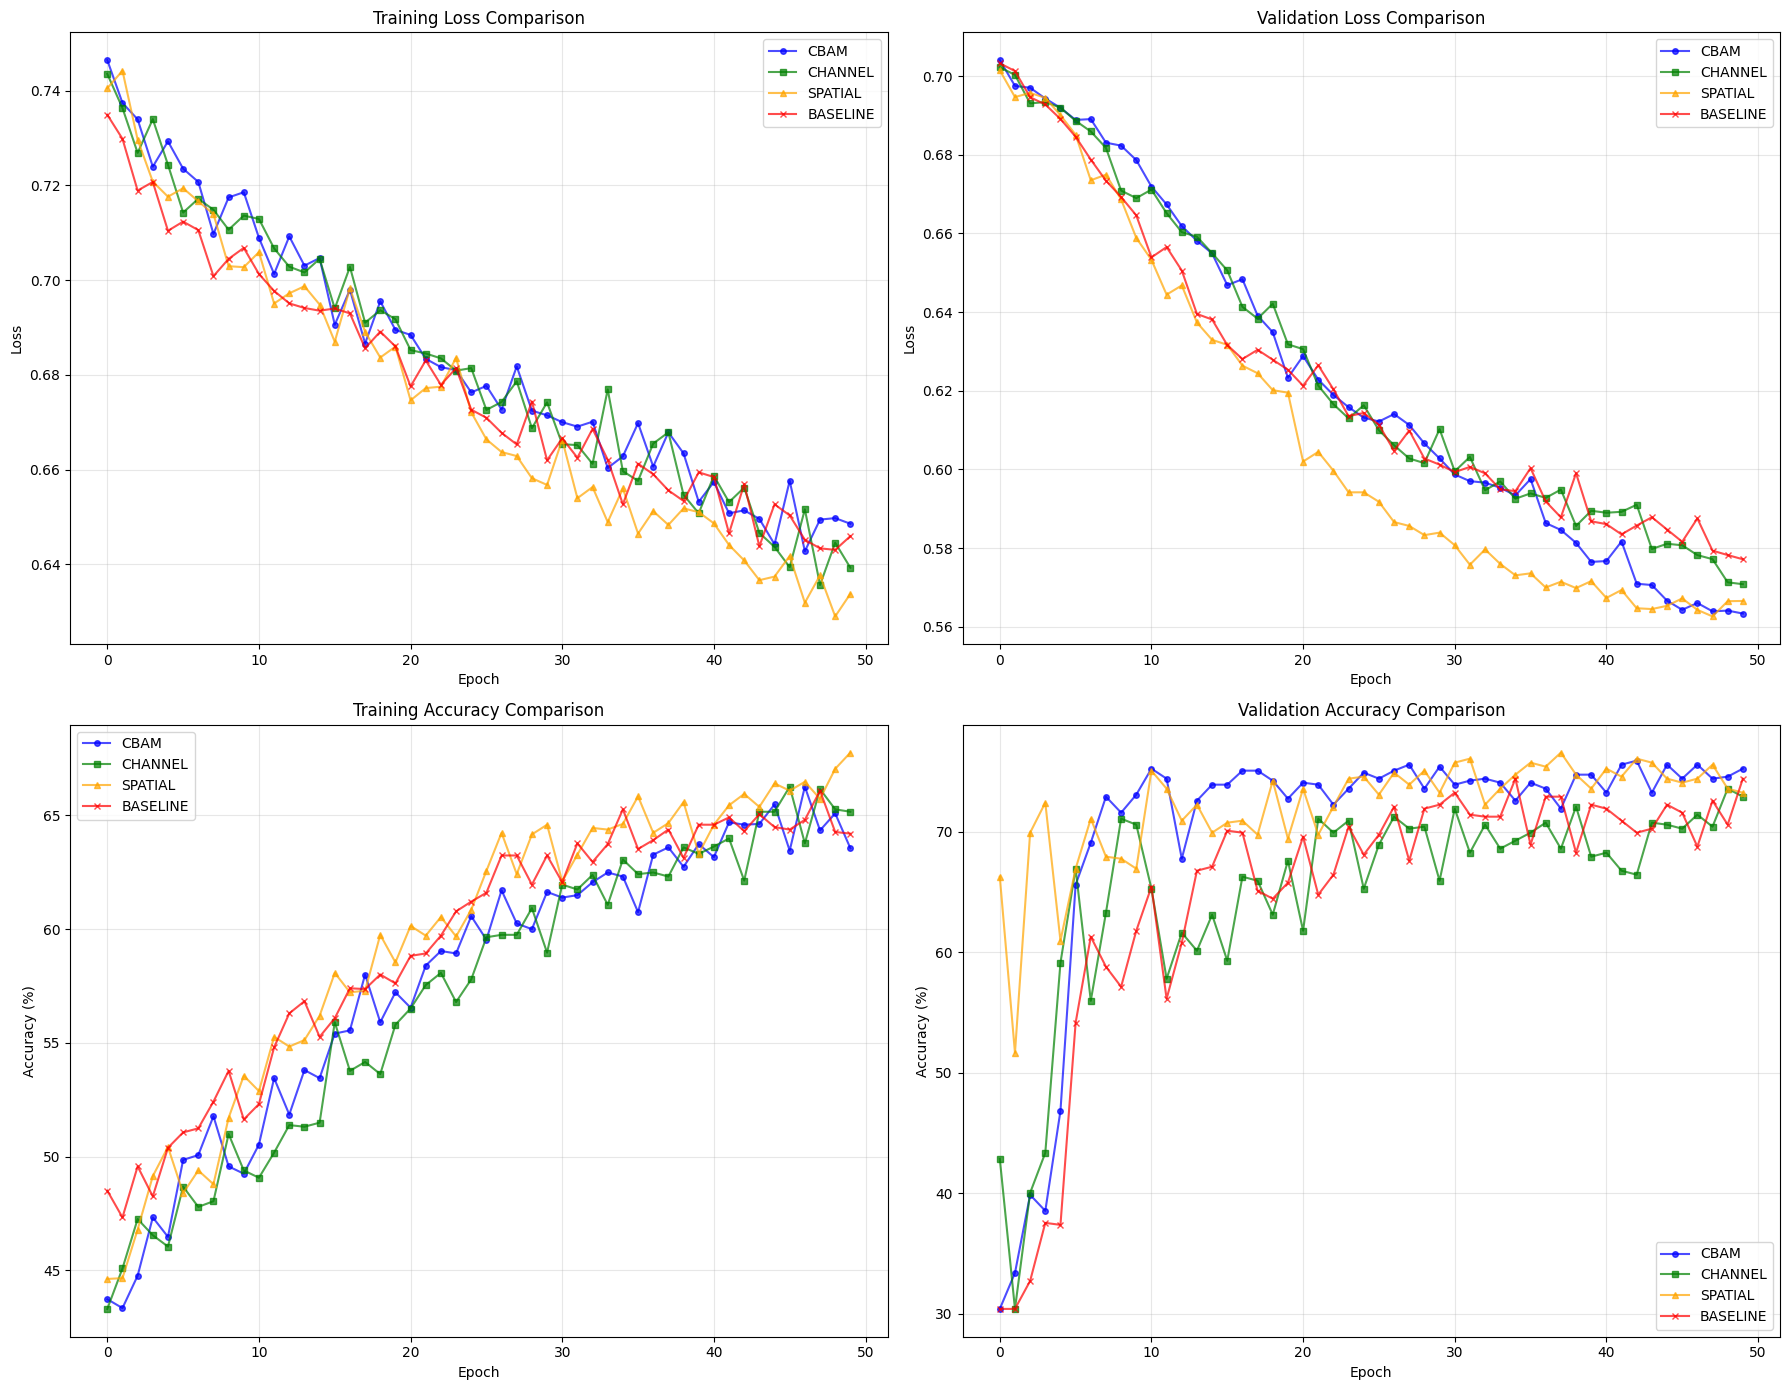

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

colors = {'cbam': 'blue', 'channel': 'green', 'spatial': 'orange', 'baseline': 'red'}
markers = {'cbam': 'o', 'channel': 's', 'spatial': '^', 'baseline': 'x'}

for model_name in results.keys():
    axes[0, 0].plot(results[model_name]['train_losses'], 
                    label=f'{model_name.upper()}', 
                    color=colors[model_name], marker=markers[model_name], 
                    markersize=4, linewidth=1.5, alpha=0.7)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for model_name in results.keys():
    axes[0, 1].plot(results[model_name]['val_losses'], 
                    label=f'{model_name.upper()}', 
                    color=colors[model_name], marker=markers[model_name], 
                    markersize=4, linewidth=1.5, alpha=0.7)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for model_name in results.keys():
    axes[1, 0].plot(results[model_name]['train_accs'], 
                    label=f'{model_name.upper()}', 
                    color=colors[model_name], marker=markers[model_name], 
                    markersize=4, linewidth=1.5, alpha=0.7)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Training Accuracy Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for model_name in results.keys():
    axes[1, 1].plot(results[model_name]['val_accs'], 
                    label=f'{model_name.upper()}', 
                    color=colors[model_name], marker=markers[model_name], 
                    markersize=4, linewidth=1.5, alpha=0.7)

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Validation Accuracy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300)
plt.show()

## Load Best Model

In [63]:
best_model_name = max(results.keys(), key=lambda k: results[k]['best_val_acc'])

models_dict = {
    'cbam': model_cbam,
    'channel': model_channel,
    'spatial': model_spatial,
    'baseline': model_baseline
}

best_model = models_dict[best_model_name]

checkpoint = torch.load(f'HitNet_{best_model_name.capitalize()}_Best.pth')
best_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model: {best_model_name.upper()}")
print(f"From epoch {checkpoint['epoch']+1}")
print(f"Val Acc: {checkpoint['val_acc']:.2f}%")

Loaded best model: SPATIAL
From epoch 48
Val Acc: 75.58%


## Evaluation

In [64]:
test_loss, test_acc, final_preds, final_labels, final_probs = validate(best_model, test_loader, criterion, device)

print(f"\nBest Model: {best_model_name.upper().replace('_', ' ')}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Best Model: SPATIAL
Test Accuracy: 71.97%
Test Loss: 0.5741


## Classification Report


Classification Report
              precision    recall  f1-score   support

        Miss     0.6350    0.6755    0.6546       188
        Land     0.8486    0.8241    0.8362       415

    accuracy                         0.7778       603
   macro avg     0.7418    0.7498    0.7454       603
weighted avg     0.7820    0.7778    0.7796       603

Miss: 127/188 = 67.55%
Land: 342/415 = 82.41%


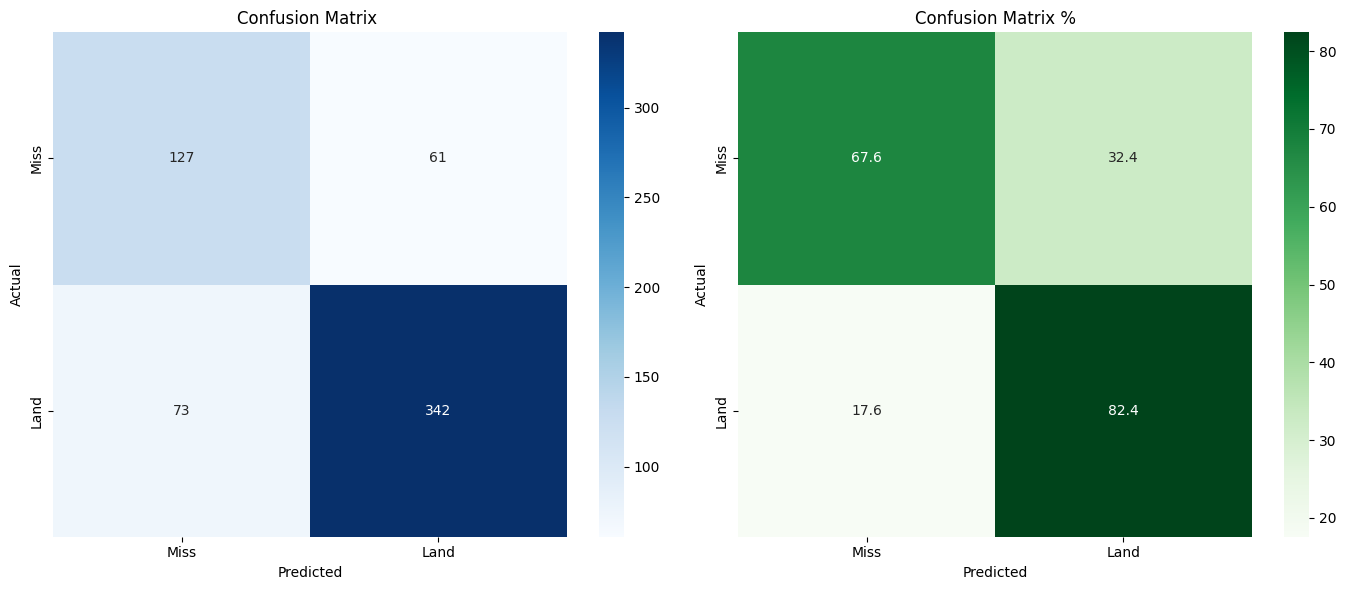

In [81]:
optimal_threshold = 0.35

optimized_preds = (y_scores > optimal_threshold).astype(int)

print(f"\nClassification Report")
print(classification_report(final_labels, optimized_preds, target_names=class_names, digits=4))

miss_indices = [i for i, label in enumerate(final_labels) if label == 0]
land_indices = [i for i, label in enumerate(final_labels) if label == 1]

miss_correct = sum([1 for i in miss_indices if optimized_preds[i] == 0])
land_correct = sum([1 for i in land_indices if optimized_preds[i] == 1])

print(f"Miss: {miss_correct}/{len(miss_indices)} = {100*miss_correct/len(miss_indices):.2f}%")
print(f"Land: {land_correct}/{len(land_indices)} = {100*land_correct/len(land_indices):.2f}%")

cm_optimized = confusion_matrix(final_labels, optimized_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix ')

cm_percent = cm_optimized.astype('float') / cm_optimized.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix %')

plt.tight_layout()
plt.savefig('confusion_matrix_optimized.png', dpi=300)
plt.show()

## ROC Curve and AUC

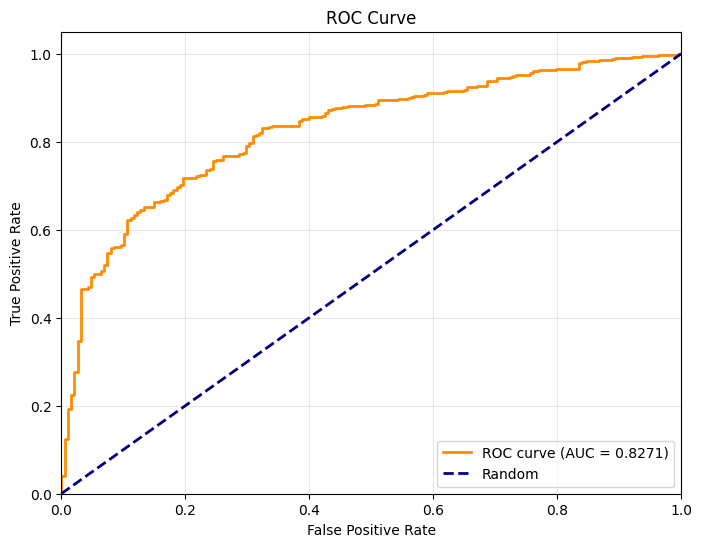

AUC Score: 0.8271


In [66]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

final_probs_array = np.array(final_probs)
y_scores = final_probs_array[:, 1]

fpr, tpr, thresholds = roc_curve(final_labels, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

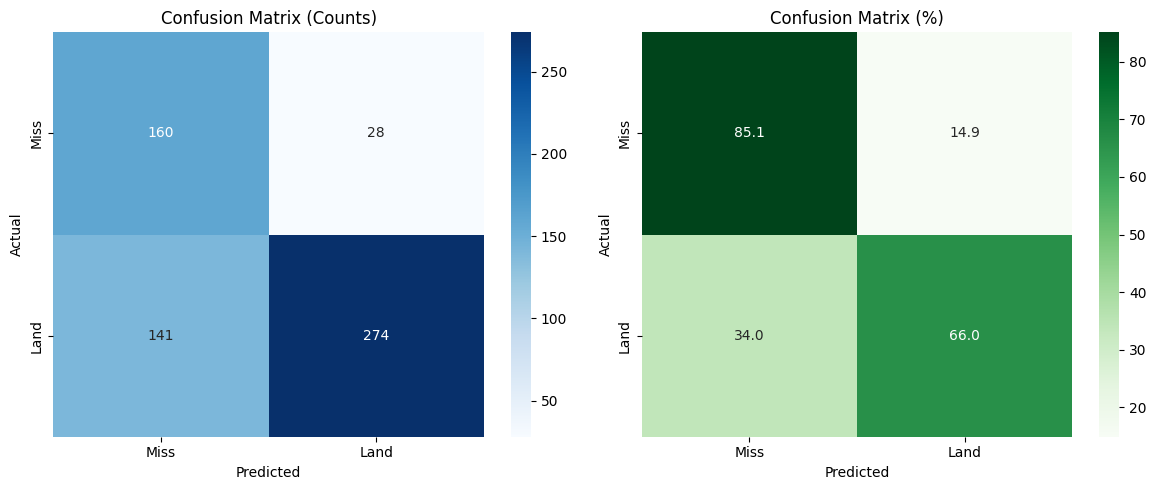

In [82]:

cm = confusion_matrix(final_labels, final_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (%)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## Save Model

In [84]:

torch.save(model.state_dict(), 'HitNet_Final.pth')
print("Model saved: HitNet_Final.pth")

Model saved: HitNet_Final.pth


## Test on Sample Images

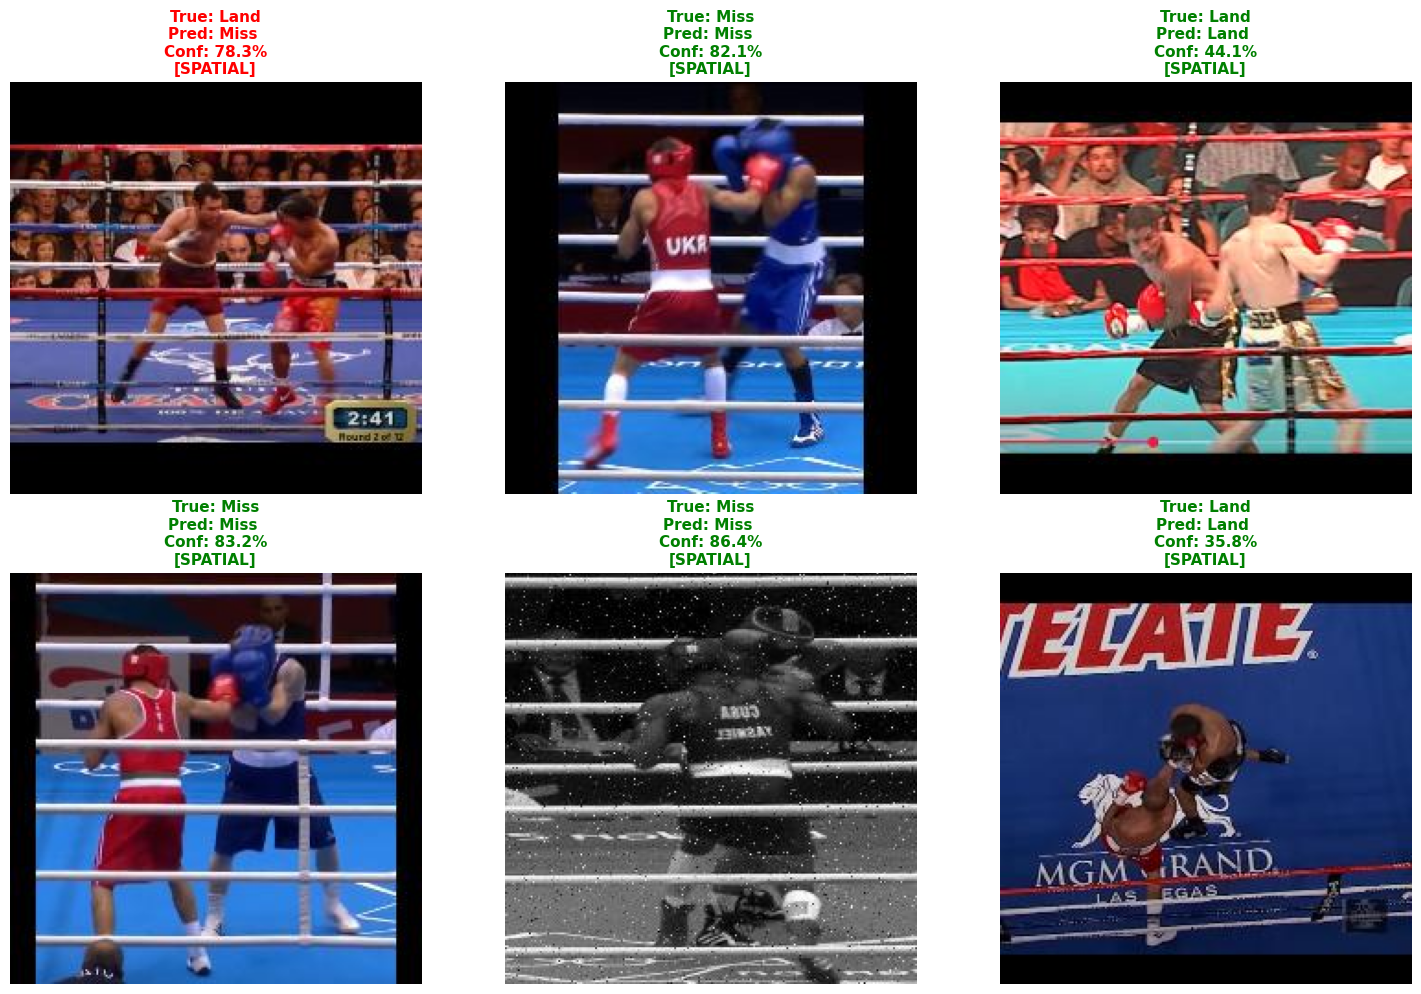

In [87]:
import random

test_split_path = os.path.join(images_path, "test")
sample_images = []

class_mapping = {
    "Hit": "land",
    "Block": "miss",
    "Miss": "miss",
    "None": "miss"
}

for src_class in ["Hit", "Miss", "Block", "None"]:
    class_dir = os.path.join(test_split_path, src_class)
    if os.path.exists(class_dir):
        class_images = [(os.path.join(class_dir, f), class_mapping[src_class]) 
                       for f in os.listdir(class_dir) 
                       if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        sample_images.extend(random.sample(class_images, min(3, len(class_images))))

random.shuffle(sample_images)
num_samples = min(len(sample_images), 9)
sample_images = sample_images[:num_samples]

optimal_threshold = 0.35

if num_samples == 0:
    print("No test images found!")
else:
    rows = (num_samples + 2) // 3
    cols = min(num_samples, 3)
    
    best_model.eval()
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.ravel() if num_samples > 1 else axes
    
    for idx, (img_path, true_label_name) in enumerate(sample_images):
        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        augmented = test_transform(image=image_rgb)
        img_tensor = torch.from_numpy(augmented['image']).permute(2, 0, 1).float().unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = best_model(img_tensor)
            probs = F.softmax(output, dim=1)
            
            land_prob = probs[0][1].item()
            pred_class = 1 if land_prob > optimal_threshold else 0
            confidence = probs[0][pred_class].item() * 100
        
        true_class = labels[true_label_name]
        pred_label = class_names[pred_class]
        true_label = class_names[true_class]
        
        color = 'green' if pred_class == true_class else 'red'
        
        ax = axes[idx] if num_samples > 1 else axes[0]
        ax.imshow(image_rgb)
        ax.axis('off')
        ax.set_title(f'True: {true_label}\nPred: {pred_label} \nConf: {confidence:.1f}%\n[{best_model_name.upper()}]', 
                           color=color, fontsize=11, fontweight='bold')
    
    for idx in range(num_samples, rows * cols):
        if idx < len(axes):
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_predictions_optimized.png', dpi=300, bbox_inches='tight')
    plt.show()